In [1]:
# ── 설치 ──
!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh
!pip install sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 45.2 MB/s eta 0:00:00
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 4.46 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-08-12 06:54:29--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.26, 104.192.142.25, 104.192.142.24, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.26|:443... connected.
HTTP request sent, a

In [2]:
# ── import ──
from konlpy.tag import Mecab
import sentencepiece as spm

In [3]:
mecab = Mecab()
print(mecab.morphs("정상적으로 설치되었는지 확인합니다"))

['정상', '적', '으로', '설치', '되', '었', '는지', '확인', '합니다']


# 1. 데이터 불러오기

In [26]:
import os
import re
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm
from konlpy.tag import Mecab

# 재현성을 위한 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# 네이버 영화리뷰 감정분석 코퍼스(NSMC) 다운로드
# ratings_train.txt / ratings_test.txt 형식: id \t document \t label
train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

if not os.path.exists('ratings_train.txt'):
  os.system(f"wget -q {train_url}")
if not os.path.exists('ratings_test.txt'):
  os.system(f"wget -q {test_url}")

train_df = pd.read_csv('ratings_train.txt', sep='\t')
test_df = pd.read_csv('ratings_test.txt', sep='\t')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Device: cuda
Train shape: (150000, 3)
Test shape: (50000, 3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


# 2. EDA

1. 기본 정보
Train shape: (144271, 3)
Test shape: (48658, 3)

Train 컬럼: ['id', 'document', 'label']

Train 샘플:
         id                                           document  label
0   9976970                                  아 더빙 진짜 짜증나네요 목소리      0
1   3819312                       흠 포스터보고 초딩영화줄 오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                         교도소 이야기구먼 솔직히 재미는 없다 평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화 스파이더맨에서 늙어보이기만 했던 커스틴 ...      1

결측치 개수 (Train):
id          0
document    0
label       0
dtype: int64

결측치 개수 (Test):
id          0
document    0
label       0
dtype: int64

2. 라벨 분포
Train label 분포:
 label
0    72424
1    71847
Name: count, dtype: int64

Test label 분포:
 label
1    24437
0    24221
Name: count, dtype: int64

Train 긍정 비율: 49.80%
Test 긍정 비율: 50.22%


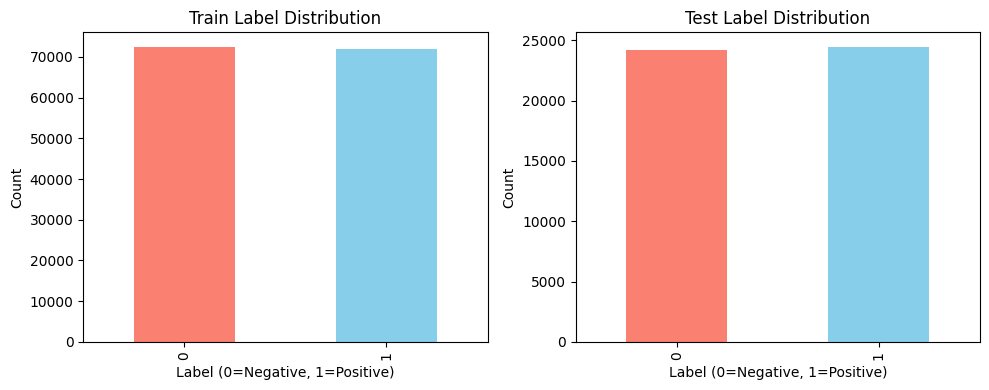


3. 중복 데이터 확인
Train 전체: 144271  / 중복 제거 후: 144271
Test 전체: 48658  / 중복 제거 후: 48658
중복 비율 (Train): 0.00%

4. 문장 길이 분포 (문자 기준)
최소 길이: 1
최대 길이: 140
평균 길이: 34.14
중앙값: 26.0
표준편차: 28.48
50퍼센타일: 26.0
75퍼센타일: 41.0
90퍼센타일: 73.0
95퍼센타일: 104.0
99퍼센타일: 134.0


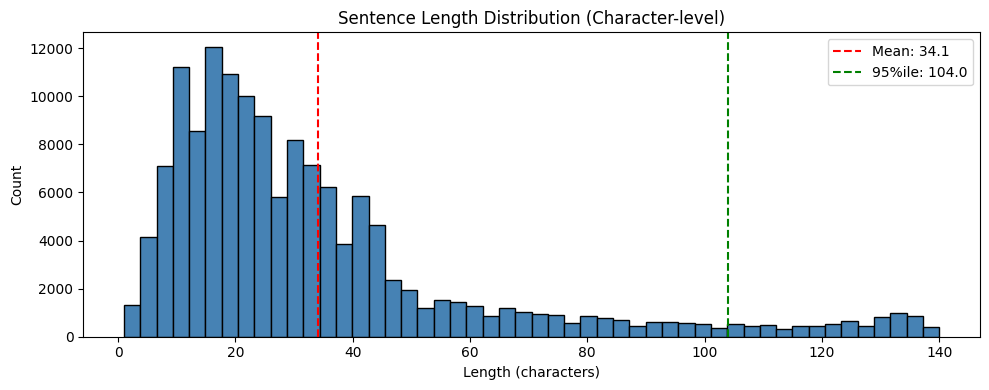

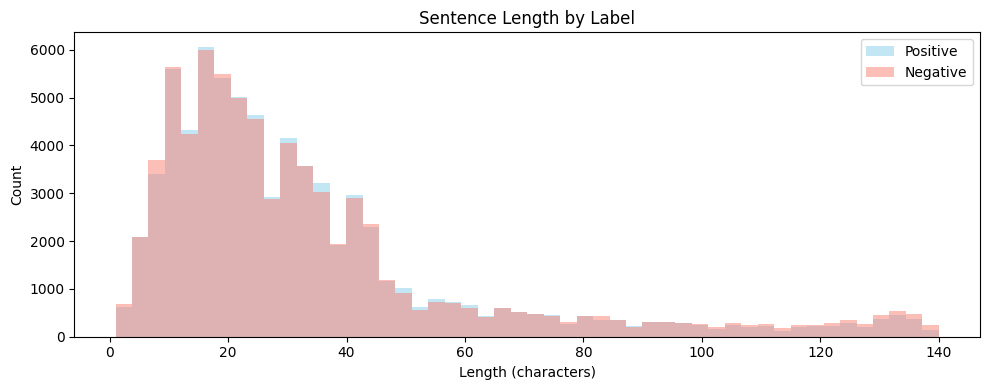


5. 특수 문자 통계
영어 포함 리뷰 비율: 5.81%
숫자 포함 리뷰 비율: 14.00%
자음/모음 반복(ㅋㅋㅋ, ㅠㅠ 등) 포함 비율: 11.31%
느낌표/물음표 포함 비율: 0.00%


In [42]:
import matplotlib.pyplot as plt
from collections import Counter

# =========================================================
# 1. 기본 정보 확인
# =========================================================
print("=" * 50)
print("1. 기본 정보")
print("=" * 50)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain 컬럼:", train_df.columns.tolist())
print("\nTrain 샘플:")
print(train_df.head())

print("\n결측치 개수 (Train):")
print(train_df.isnull().sum())
print("\n결측치 개수 (Test):")
print(test_df.isnull().sum())

# =========================================================
# 2. 라벨(긍정/부정) 분포 확인
# =========================================================
print("\n" + "=" * 50)
print("2. 라벨 분포")
print("=" * 50)
print("Train label 분포:\n", train_df['label'].value_counts())
print("\nTest label 분포:\n", test_df['label'].value_counts())
print("\nTrain 긍정 비율: {:.2f}%".format(train_df['label'].mean() * 100))
print("Test 긍정 비율: {:.2f}%".format(test_df['label'].mean() * 100))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['salmon', 'skyblue']
)
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Label (0=Negative, 1=Positive)")
axes[0].set_ylabel("Count")

test_df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['salmon', 'skyblue']
)
axes[1].set_title("Test Label Distribution")
axes[1].set_xlabel("Label (0=Negative, 1=Positive)")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

# =========================================================
# 3. 중복 문장 확인
# =========================================================
print("\n" + "=" * 50)
print("3. 중복 데이터 확인")
print("=" * 50)
print("Train 전체:", len(train_df), " / 중복 제거 후:", train_df['document'].nunique())
print("Test 전체:", len(test_df), " / 중복 제거 후:", test_df['document'].nunique())
print("중복 비율 (Train): {:.2f}%".format(
    (1 - train_df['document'].nunique() / len(train_df)) * 100
))

# =========================================================
# 4. 문장 길이 분포 (문자 기준)
# =========================================================
print("\n" + "=" * 50)
print("4. 문장 길이 분포 (문자 기준)")
print("=" * 50)

train_char_len = train_df['document'].astype(str).apply(len)

print("최소 길이:", train_char_len.min())
print("최대 길이:", train_char_len.max())
print("평균 길이: {:.2f}".format(train_char_len.mean()))
print("중앙값:", train_char_len.median())
print("표준편차: {:.2f}".format(train_char_len.std()))
for p in [50, 75, 90, 95, 99]:
    print(f"{p}퍼센타일: {np.percentile(train_char_len, p):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(train_char_len, bins=50, color='steelblue', edgecolor='black')
plt.axvline(train_char_len.mean(), color='red', linestyle='--', label=f'Mean: {train_char_len.mean():.1f}')
plt.axvline(np.percentile(train_char_len, 95), color='green', linestyle='--', label=f'95%ile: {np.percentile(train_char_len, 95):.1f}')
plt.title("Sentence Length Distribution (Character-level)")
plt.xlabel("Length (characters)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 라벨별 길이 분포 비교 (긍정 vs 부정 리뷰 길이 차이 확인)
plt.figure(figsize=(10, 4))
plt.hist(train_df[train_df['label']==1]['document'].astype(str).apply(len),
         bins=50, alpha=0.5, label='Positive', color='skyblue')
plt.hist(train_df[train_df['label']==0]['document'].astype(str).apply(len),
         bins=50, alpha=0.5, label='Negative', color='salmon')
plt.title("Sentence Length by Label")
plt.xlabel("Length (characters)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 5. 특수 문자 확인 (자음/모음 반복, 숫자, 영어 포함 비율 등)
# =========================================================
print("\n" + "=" * 50)
print("5. 특수 문자 통계")
print("=" * 50)

def contains_pattern(series, pattern):
    return series.astype(str).str.contains(pattern, regex=True).mean() * 100

print("영어 포함 리뷰 비율: {:.2f}%".format(contains_pattern(train_df['document'], r'[a-zA-Z]')))
print("숫자 포함 리뷰 비율: {:.2f}%".format(contains_pattern(train_df['document'], r'[0-9]')))
print("자음/모음 반복(ㅋㅋㅋ, ㅠㅠ 등) 포함 비율: {:.2f}%".format(
    contains_pattern(train_df['document'], r'[ㄱ-ㅎㅏ-ㅣ]{2,}')
))
print("느낌표/물음표 포함 비율: {:.2f}%".format(contains_pattern(train_df['document'], r'[!?]')))

# 3. 데이터 전처리

In [44]:
def clean_text(text):
  # 한글, 영문, 숫자, 공백만 남기고 전부 제거
  text = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9a-zA-Z ]", " ", str(text))
  # 중복 공백 정리
  text = re.sub(r"\s+", " ", text).strip()
  return text

train_df['document'] = train_df['document'].apply(clean_text)
test_df['document'] = test_df['document'].apply(clean_text)

# 빈 문자열이 된 행 제거
train_df = train_df[train_df['document'].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df['document'].str.len() > 0].reset_index(drop=True)

print("정제 후 Train size:", len(train_df))
print("정제 후 Test size:", len(test_df))
print("라벨 분포(Train):\n", train_df['label'].value_counts())

MAX_LEN = 104  # 상위 95% 커버하는 길이로 maxlen 설정(EDA 결과)

정제 후 Train size: 144271
정제 후 Test size: 48658
라벨 분포(Train):
 label
0    72424
1    71847
Name: count, dtype: int64


# 4. SentencePiece 토크나이저 학습

In [28]:
def train_sentencepiece(corpus, model_prefix, vocab_size=8000, model_type='bpe'):
  """
  corpus: 문자열 리스트
  model_prefix: 저장될 모델 파일 접두사
  vacab_size: 사전 크기
  model_type: 'bpe', 'unigram', 'char', 'word' 중 선택
  """
  temp_file = f"{model_prefix}_temp.txt"
  with open(temp_file, 'w', encoding='utf-8') as f:
    for row in corpus:
      f.write(str(row) + '\n')

  spm.SentencePieceTrainer.Train(
      f"--input={temp_file} --model_prefix={model_prefix} "
      f"--vocab_size={vocab_size} --model_type={model_type} "
      f"--pad_id=0 --unk_id=1 --bos_id=2 --eos_id=3"
  )
  os.remove(temp_file)
  print(f"[완료] {model_prefix}.model / {model_prefix}.vocab 생성 (vocab_size={vocab_size}, type={model_type})")

train_corpus = train_df['document'].tolist()

# 기본 SentencePiece 모델 학습 (BPE, vocab_size=8000)
train_sentencepiece(train_corpus, model_prefix='nsmc_spm_bpe_8000', vocab_size=8000, model_type='bpe')

[완료] nsmc_spm_bpe_8000.model / nsmc_spm_bpe_8000.vocab 생성 (vocab_size=8000, type=bpe)


# 5. 문장을 숫자로 변환(encoding)

In [32]:
def sp_tokenize(sp_model, corpus, max_len=None):
  """
  sp_model: 로드된 SentencePieceProcessor 객체
  corpus: 문자열 리스트
  max_len: 지정 시 해당 길이로 자르거나 패딩, None이면 배치 내 최대 길이로 자동 패딩
  반환값: 패딩된 텐서, word_index, index_word
  """
  tensor = []
  for sen in corpus:
    ids = sp_model.EncodeAsIds(sen)
    if max_len is not None:
      ids = ids[:max_len]
    tensor.append(torch.tensor(ids, dtype=torch.long))

  vocab_size = sp_model.GetPieceSize()
  word_index = {sp_model.IdToPiece(i): i for i in range(vocab_size)}
  index_word = {i: sp_model.IdToPiece(i) for i in range(vocab_size)}

  tensor = pad_sequence(tensor, batch_first=True, padding_value=0)

  if max_len is not None and tensor.size(1) < max_len:
    pad_amount = max_len - tensor.size(1)
    tensor = torch.nn.functional.pad(tensor, (0, pad_amount), value=0)

  return tensor, word_index, index_word

class TextDataset(Dataset):
  def __init__(self, encoded_tensor, labels):
    self.x = encoded_tensor
    self.y = torch.tensor(labels, dtype=torch.float32)
    # 각 문장에서 0이 아닌 토큰 개수를 실제 길이로 계산 (최소 1 보장)
    self.lengths = (encoded_tensor != 0).sum(dim=1).clamp(min=1)

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx], self.lengths[idx]

# 6. AI 모델 정의 (LSTM)

In [36]:
from torch.nn.utils.rnn import pack_padded_sequence

class Model_1(nn.Module):
  def __init__(self, vocab_size, word_vector_dim, pad_idx=0):
    super(Model_1, self).__init__()
    self.embedding = nn.Embedding(vocab_size, word_vector_dim, padding_idx=pad_idx)
    self.lstm = nn.LSTM(word_vector_dim, 32, batch_first=True)
    self.fc1 = nn.Linear(32, 16)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(16, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, x, lengths):
    x = self.embedding(x)
    lstm_out, (h_n, c_n) = self.lstm(x)

    # 실제 길이(패딩 제외)만큼만 LSTM이 처리하도록 압축
    packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
    packed_out, (h_n, c_n) = self.lstm(packed)

    x = h_n[-1]
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.sigmoid(x)
    return x

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
  model.to(device)
  criterion = nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)

  history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

  for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x_batch, y_batch, len_batch in train_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      optimizer.zero_grad()
      output = model(x_batch, len_batch).squeeze(1)
      loss = criterion(output, y_batch)
      loss.backward()
      optimizer.step()
      total_loss += loss.item() * x_batch.size(0)
    train_loss = total_loss / len(train_loader.dataset)

    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
      for x_batch, y_batch, len_batch in val_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model(x_batch, len_batch).squeeze(1)
        loss = criterion(output, y_batch)
        val_loss += loss.item() * x_batch.size(0)
        preds = (output > 0.5).float()
        correct += (preds == y_batch).sum().item()
    val_loss /= len(val_loader.dataset)
    val_acc = correct / len(val_loader.dataset)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

  return history

def evaluate_model(model, test_loader):
  model.eval()
  correct = 0
  with torch.no_grad():
    for x_batch, y_batch, len_batch in test_loader:
      x_batch, y_batch = x_batch.to(device), y_batch.to(device)
      output = model(x_batch, len_batch).squeeze(1)
      preds = (output > 0.5).float()
      correct += (preds == y_batch).sum().item()
  acc = correct / len(test_loader.dataset)
  return acc

# 7. 학습

### SentencePiece

In [37]:
sp = spm.SentencePieceProcessor()
sp.load('nsmc_spm_bpe_8000.model')

x_train_ids, word_index_sp, index_word_sp = sp_tokenize(sp, train_df['document'].tolist(), max_len=MAX_LEN)
x_test_ids, _, _ = sp_tokenize(sp, test_df['document'].tolist(), max_len=MAX_LEN)

y_train = train_df['label'].tolist()
y_test = test_df['label'].tolist()

# train / validation 분리
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(x_train_ids, y_train, test_size=0.1, random_state=SEED, stratify=y_train)

train_ds = TextDataset(x_tr, y_tr)
val_ds = TextDataset(x_val, y_val)
test_ds = TextDataset(x_test_ids, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256)
test_loader = DataLoader(test_ds, batch_size=256)

vocab_size_sp = sp.GetPieceSize()
model_sp = Model_1(vocab_size_sp, word_vector_dim=64)

print(">> SentencePiece 기반 모델 학습 시작")
history_sp = train_model(model_sp, train_loader, val_loader, epochs=20)

test_acc_sp = evaluate_model(model_sp, test_loader)
print(f"[SentencePiece] Test Accuracy: {test_acc_sp:.4f}")

>> SentencePiece 기반 모델 학습 시작
Epoch 1/20 | train_loss: 0.5099 | val_loss: 0.4058 | val_acc: 0.8163
Epoch 2/20 | train_loss: 0.3609 | val_loss: 0.3689 | val_acc: 0.8372
Epoch 3/20 | train_loss: 0.3185 | val_loss: 0.3595 | val_acc: 0.8427
Epoch 4/20 | train_loss: 0.2913 | val_loss: 0.3618 | val_acc: 0.8438
Epoch 5/20 | train_loss: 0.2692 | val_loss: 0.3715 | val_acc: 0.8440
Epoch 6/20 | train_loss: 0.2470 | val_loss: 0.3762 | val_acc: 0.8431
Epoch 7/20 | train_loss: 0.2261 | val_loss: 0.3932 | val_acc: 0.8429
Epoch 8/20 | train_loss: 0.2052 | val_loss: 0.4094 | val_acc: 0.8423
Epoch 9/20 | train_loss: 0.1846 | val_loss: 0.4387 | val_acc: 0.8385
Epoch 10/20 | train_loss: 0.1645 | val_loss: 0.4634 | val_acc: 0.8347
Epoch 11/20 | train_loss: 0.1438 | val_loss: 0.5147 | val_acc: 0.8346
Epoch 12/20 | train_loss: 0.1264 | val_loss: 0.5567 | val_acc: 0.8343
Epoch 13/20 | train_loss: 0.1100 | val_loss: 0.6184 | val_acc: 0.8317
Epoch 14/20 | train_loss: 0.0974 | val_loss: 0.6630 | val_acc: 0.8292


### Mecab

In [38]:
mecab = Mecab()

class SimpleTokenizer:
    """기존에 구현했던 Tokenizer 클래스 (공백/형태소 리스트 입력 모두 지원)"""
    def __init__(self):
        self.word_index = {'<PAD>': 0, '<UNK>': 1}
        self.index_word = {0: '<PAD>', 1: '<UNK>'}

    def fit_on_texts(self, corpus):
        for tokens in corpus:
            for token in tokens:
                if token not in self.word_index:
                    idx = len(self.word_index)
                    self.word_index[token] = idx
                    self.index_word[idx] = token

    def texts_to_sequences(self, corpus, max_len=None):
        sequences = []
        for tokens in corpus:
            if max_len is not None:
                tokens = tokens[:max_len]
            seq = [self.word_index.get(t, 1) for t in tokens]  # UNK=1
            sequences.append(torch.tensor(seq, dtype=torch.long))
        return sequences

# Mecab으로 형태소 분석
print(">> Mecab 형태소 분석 중...")
mecab_train_corpus = [mecab.morphs(sen) for sen in train_df['document'].tolist()]
mecab_test_corpus = [mecab.morphs(sen) for sen in test_df['document'].tolist()]

mecab_tokenizer = SimpleTokenizer()
mecab_tokenizer.fit_on_texts(mecab_train_corpus)

mecab_train_seq = mecab_tokenizer.texts_to_sequences(mecab_train_corpus, max_len=MAX_LEN)
mecab_test_seq = mecab_tokenizer.texts_to_sequences(mecab_test_corpus, max_len=MAX_LEN)

mecab_train_tensor = pad_sequence(mecab_train_seq, batch_first=True, padding_value=0)
mecab_test_tensor = pad_sequence(mecab_test_seq, batch_first=True, padding_value=0)

# train/val 분리 (SentencePiece 실험과 동일 비율)
mx_tr, mx_val, my_tr, my_val = train_test_split(
    mecab_train_tensor, y_train, test_size=0.1, random_state=SEED, stratify=y_train
)

mecab_train_ds = TextDataset(mx_tr, my_tr)
mecab_val_ds = TextDataset(mx_val, my_val)
mecab_test_ds = TextDataset(mecab_test_tensor, y_test)

mecab_train_loader = DataLoader(mecab_train_ds, batch_size=128, shuffle=True)
mecab_val_loader = DataLoader(mecab_val_ds, batch_size=256)
mecab_test_loader = DataLoader(mecab_test_ds, batch_size=256)

vocab_size_mecab = len(mecab_tokenizer.word_index)
model_mecab = Model_1(vocab_size_mecab, word_vector_dim=64)

print(">> Mecab 기반 모델 학습 시작")
history_mecab = train_model(model_mecab, mecab_train_loader, mecab_val_loader, epochs=20)

test_acc_mecab = evaluate_model(model_mecab, mecab_test_loader)
print(f"[Mecab] Test Accuracy: {test_acc_mecab:.4f}")
print(f"[SentencePiece] vocab_size={vocab_size_sp} | Test Accuracy: {test_acc_sp:.4f}")
print(f"[Mecab]         vocab_size={vocab_size_mecab} | Test Accuracy: {test_acc_mecab:.4f}")

>> Mecab 형태소 분석 중...
>> Mecab 기반 모델 학습 시작
Epoch 1/20 | train_loss: 0.4678 | val_loss: 0.3859 | val_acc: 0.8272
Epoch 2/20 | train_loss: 0.3431 | val_loss: 0.3543 | val_acc: 0.8458
Epoch 3/20 | train_loss: 0.2955 | val_loss: 0.3465 | val_acc: 0.8519
Epoch 4/20 | train_loss: 0.2588 | val_loss: 0.3494 | val_acc: 0.8549
Epoch 5/20 | train_loss: 0.2258 | val_loss: 0.3558 | val_acc: 0.8576
Epoch 6/20 | train_loss: 0.1976 | val_loss: 0.3710 | val_acc: 0.8553
Epoch 7/20 | train_loss: 0.1723 | val_loss: 0.3912 | val_acc: 0.8538
Epoch 8/20 | train_loss: 0.1515 | val_loss: 0.4230 | val_acc: 0.8493
Epoch 9/20 | train_loss: 0.1327 | val_loss: 0.4350 | val_acc: 0.8502
Epoch 10/20 | train_loss: 0.1171 | val_loss: 0.4841 | val_acc: 0.8478
Epoch 11/20 | train_loss: 0.1018 | val_loss: 0.5140 | val_acc: 0.8469
Epoch 12/20 | train_loss: 0.0917 | val_loss: 0.5357 | val_acc: 0.8468
Epoch 13/20 | train_loss: 0.0783 | val_loss: 0.5845 | val_acc: 0.8436
Epoch 14/20 | train_loss: 0.0688 | val_loss: 0.6212 | val

### SentencePiece 설정을 바꿔가며 실험

In [39]:
def run_sp_experiment(model_type, vocab_size, epochs=8):
    prefix = f"nsmc_spm_{model_type}_{vocab_size}"
    train_sentencepiece(train_corpus, model_prefix=prefix, vocab_size=vocab_size, model_type=model_type)

    sp_exp = spm.SentencePieceProcessor()
    sp_exp.load(f"{prefix}.model")

    x_tr_ids, _, _ = sp_tokenize(sp_exp, train_df['document'].tolist(), max_len=MAX_LEN)
    x_te_ids, _, _ = sp_tokenize(sp_exp, test_df['document'].tolist(), max_len=MAX_LEN)

    xt, xv, yt, yv = train_test_split(x_tr_ids, y_train, test_size=0.1, random_state=SEED, stratify=y_train)

    tr_loader = DataLoader(TextDataset(xt, yt), batch_size=128, shuffle=True)
    va_loader = DataLoader(TextDataset(xv, yv), batch_size=256)
    te_loader = DataLoader(TextDataset(x_te_ids, y_test), batch_size=256)

    model_exp = Model_1(sp_exp.GetPieceSize(), word_vector_dim=64)
    hist = train_model(model_exp, tr_loader, va_loader, epochs=epochs)
    acc = evaluate_model(model_exp, te_loader)

    return {
        'model_type': model_type,
        'vocab_size': vocab_size,
        'test_acc': acc,
        'final_val_acc': hist['val_acc'][-1]
    }

# 비교 실험: model_type(bpe vs unigram) x vocab_size(4000, 8000, 16000)
experiment_configs = [
    ('bpe', 4000),
    ('bpe', 8000),
    ('bpe', 16000),
    ('unigram', 4000),
    ('unigram', 8000),
    ('unigram', 16000),
]

results = []
for model_type, vsize in experiment_configs:
    print(f"\n===== 실험: model_type={model_type}, vocab_size={vsize} =====")
    result = run_sp_experiment(model_type, vsize, epochs=8)
    results.append(result)
    print(result)

results_df = pd.DataFrame(results)
print("\n최종 비교 결과:")
print(results_df.sort_values('test_acc', ascending=False))


===== 실험: model_type=bpe, vocab_size=4000 =====
[완료] nsmc_spm_bpe_4000.model / nsmc_spm_bpe_4000.vocab 생성 (vocab_size=4000, type=bpe)
Epoch 1/8 | train_loss: 0.4966 | val_loss: 0.4051 | val_acc: 0.8208
Epoch 2/8 | train_loss: 0.3672 | val_loss: 0.3705 | val_acc: 0.8373
Epoch 3/8 | train_loss: 0.3351 | val_loss: 0.3597 | val_acc: 0.8411
Epoch 4/8 | train_loss: 0.3154 | val_loss: 0.3542 | val_acc: 0.8452
Epoch 5/8 | train_loss: 0.2977 | val_loss: 0.3573 | val_acc: 0.8465
Epoch 6/8 | train_loss: 0.2810 | val_loss: 0.3700 | val_acc: 0.8436
Epoch 7/8 | train_loss: 0.2645 | val_loss: 0.3698 | val_acc: 0.8393
Epoch 8/8 | train_loss: 0.2482 | val_loss: 0.3793 | val_acc: 0.8405
{'model_type': 'bpe', 'vocab_size': 4000, 'test_acc': 0.8401701672900653, 'final_val_acc': 0.8405184363737178}

===== 실험: model_type=bpe, vocab_size=8000 =====
[완료] nsmc_spm_bpe_8000.model / nsmc_spm_bpe_8000.vocab 생성 (vocab_size=8000, type=bpe)
Epoch 1/8 | train_loss: 0.5122 | val_loss: 0.4127 | val_acc: 0.8143
Epoch 2

# 8. 실험 결과 시각화
- SentencePiece vs Mecab 비교
- bpe/unigram × 4000/8000/16000

                        method  vocab_size  test_acc
 SentencePiece (unigram, 4000)        4000  0.842081
     SentencePiece (bpe, 4000)        4000  0.840170
 SentencePiece (unigram, 8000)        8000  0.839574
     SentencePiece (bpe, 8000)        8000  0.837375
SentencePiece (unigram, 16000)       16000  0.837026
    SentencePiece (bpe, 16000)       16000  0.835854
              Mecab (morpheme)       52227  0.834560
     SentencePiece (BPE, 8000)        8000  0.825291


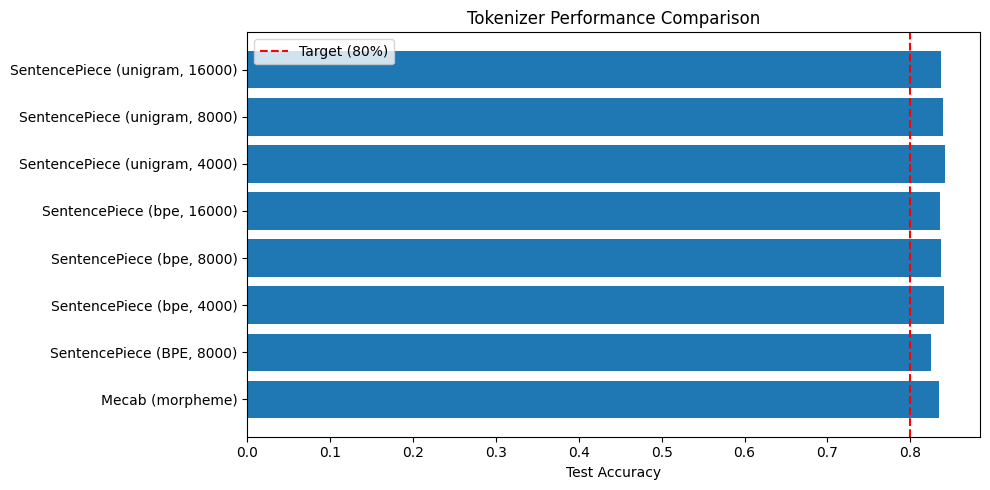

In [41]:
final_comparison = pd.DataFrame([
    {'method': 'Mecab (morpheme)', 'vocab_size': vocab_size_mecab, 'test_acc': test_acc_mecab},
    {'method': 'SentencePiece (BPE, 8000)', 'vocab_size': vocab_size_sp, 'test_acc': test_acc_sp},
] + [
    {'method': f"SentencePiece ({r['model_type']}, {r['vocab_size']})", 'vocab_size': r['vocab_size'], 'test_acc': r['test_acc']}
    for r in results
])

print(final_comparison.sort_values('test_acc', ascending=False).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(final_comparison['method'], final_comparison['test_acc'])
plt.xlabel("Test Accuracy")
plt.title("Tokenizer Performance Comparison")
plt.axvline(x=0.80, color='red', linestyle='--', label='Target (80%)')
plt.legend()
plt.tight_layout()
plt.show()

# 9. 결과 분석

## 1. 전체적인 결과

가장 높은 성능을 보인 방법은 **SentencePiece Unigram, Vocabulary Size 4,000**으로, 테스트 정확도는 **0.842081**이었다.

반면 Mecab의 테스트 정확도는 **0.834560**으로 SentencePiece Unigram 4,000보다 약 **0.75%p 낮았다**.

따라서 이번 실험에서는 전통적인 형태소 분석기인 Mecab보다 SentencePiece를 사용한 경우가 전반적으로 더 높은 분류 성능을 보였다.

## 2. SentencePiece Vocabulary Size에 따른 변화

SentencePiece에서는 Vocabulary Size가 증가할수록 성능이 오히려 감소하는 경향이 나타났다.

### Unigram

* 4,000 → **0.842081**
* 8,000 → 0.839574
* 16,000 → 0.837026

Vocabulary Size가 4,000에서 16,000으로 증가하면서 정확도가 약 **0.51%p 감소**하였다.

### BPE

* 4,000 → **0.840170**
* 8,000 → 0.837375
* 16,000 → 0.835854

BPE 역시 Vocabulary Size가 증가할수록 정확도가 감소하였다.

이는 Vocabulary가 지나치게 커지면서 토큰이 더 세분화되지 않고 상대적으로 긴 단위로 구성되거나 학습 데이터에서 각 토큰이 등장하는 빈도가 낮아져 모델이 일반화하기 어려워졌기 때문으로 해석할 수 있다.

즉, 이번 데이터에서는 **큰 Vocabulary가 반드시 더 좋은 성능을 보장하지 않았다.**

## 3. Unigram과 BPE 비교

동일한 Vocabulary Size에서 Unigram과 BPE를 비교하면 모든 경우에서 **Unigram의 성능이 BPE보다 높았다.**

| Vocabulary Size |  Unigram |      BPE |        차이 |
| --------------: | -------: | -------: | --------: |
|           4,000 | 0.842081 | 0.840170 | +0.001911 |
|           8,000 | 0.839574 | 0.837375 | +0.002199 |
|          16,000 | 0.837026 | 0.835854 | +0.001172 |

따라서 이번 데이터에서는 **BPE보다 Unigram 방식이 더 적합한 토큰화 방식**으로 나타났다.

특히 Vocabulary Size 4,000에서 Unigram이 가장 높은 성능을 기록했기 때문에 제한된 Vocabulary를 효율적으로 활용하면서 문맥에 적합한 토큰 조합을 선택하는 Unigram의 특성이 이번 분류 문제에서 유리하게 작용했을 가능성이 있다.

## 4. Mecab과 SentencePiece 비교

Mecab은 형태소 단위로 텍스트를 분리하기 때문에 사람이 이해하기 쉬운 언어학적 단위로 토큰화할 수 있다는 장점이 있다.

하지만 이번 실험에서는 Mecab의 정확도가 **0.834560**으로, SentencePiece의 모든 설정 중 대부분보다 낮았다.

특히 SentencePiece Unigram 4,000은 **0.842081**로 Mecab보다 약 **0.007521 높은 정확도**를 기록했다.

이는 해당 데이터에서는 반드시 형태소 단위로 분리하는 것보다 SentencePiece가 데이터에 맞는 서브워드 단위를 학습하는 방식이 분류 문제에 더 효과적이었음을 의미한다.

## 5. 최종적으로 가장 좋은 설정

이번 실험에서 가장 좋은 성능을 보인 설정은 다음과 같다.

* Tokenizer: **SentencePiece**
* Algorithm: **Unigram**
* Vocabulary Size: **4,000**
* Test Accuracy: **0.842081**

따라서 이번 데이터에서는 **SentencePiece + Unigram + Vocabulary Size 4,000** 조합을 가장 적합한 토큰화 방식으로 판단할 수 있다.

## 6. 결론

이번 실험 결과, SentencePiece는 Mecab보다 높은 테스트 정확도를 보였으며 SentencePiece 내부에서는 **BPE보다 Unigram이 더 높은 성능**을 보였다.

또한 Vocabulary Size는 클수록 좋은 것이 아니었으며, 오히려 **4,000에서 가장 높은 성능**이 나타났다. Vocabulary Size를 8,000과 16,000으로 증가시키면서 성능이 점차 감소했기 때문에, 이번 데이터에서는 적절한 크기의 Vocabulary를 사용하는 것이 중요하다는 것을 확인할 수 있었다.

이번 실험에서는 **SentencePiece Unigram, Vocabulary Size 4,000이 가장 효율적인 토큰화 방법**이라고 결론내릴 수 있다.




---





---





---



# 오류와 해결 방법

- **MAX_LEN을 char 기준으로 계산**을 해서 padding 갯수가 늘어난 이유 때문에 SentencePiece 학습이 제대로 이루어지지 않았음
  - LSTM은 패딩 여부를 구분하지 않고 끝까지 순차적으로 hidden state를 갱신하기 때문에 문장 뒷부분에 패딩 수가 증가할 수록 앞부분의 의미가 손실됨

- 이를 해결하고자 **pack_padded_sequence**로 **LSTM이 패딩을 아예 무시하도록 처리**하였음

- 아래 코드는 코드 수정 전에 실행했던 결과이며 문자 길아와 토큰의 길이에 큰 차이가 있음을 알 수 있음

In [25]:
sp_lengths = train_df['document'].apply(
    lambda x: len(sp.encode(x, out_type=int))
)

print("문자 길이 95%:", np.percentile(lengths, 95))
print("SP token 길이 95%:", np.percentile(sp_lengths, 95))
print("SP token 최대:", sp_lengths.max())
print("SP token 평균:", sp_lengths.mean())

문자 길이 95%: 104.0
SP token 길이 95%: 47.0
SP token 최대: 116
SP token 평균: 15.525649645458893
